# Momentum + Value Strat: Quant Project Run 2

## Revamping Strategy to get better results

### 1. By changing my universe of tickers to the ones in S&P500 and 
### 2. Changing the time range of the data I get to 10 years.
### 3. Understanding my factors in depth and maybe eliminate correlatation between them
### 4. Eliminated some factors and introduce others (eg. value)
### 5. Change how portfolio is being constructed

In [1]:
# Our usual imports 
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import datetime
import pandas as pd

### First, lets change our universe of stocks

In [2]:
import requests
import pandas as pd

url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
resp = requests.get(url, headers=headers)
resp.raise_for_status()
sp500_table = pd.read_html(resp.text)[0]
univ = sp500_table['Symbol'].str.replace('.', '-', regex=False).tolist()

C:\Users\mroha\AppData\Local\Temp\ipykernel_30796\2538594183.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500_table = pd.read_html(resp.text)[0]


### Changing the time range

In [3]:
# Make datetime arrays consisting of monthly dates for the last 2 years
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=365*10)
dates = pd.date_range(start=start_date, end=end_date, freq='ME')
dates = dates.normalize()
dates

DatetimeIndex(['2016-04-30', '2016-05-31', '2016-06-30', '2016-07-31',
               '2016-08-31', '2016-09-30', '2016-10-31', '2016-11-30',
               '2016-12-31', '2017-01-31',
               ...
               '2025-06-30', '2025-07-31', '2025-08-31', '2025-09-30',
               '2025-10-31', '2025-11-30', '2025-12-31', '2026-01-31',
               '2026-02-28', '2026-03-31'],
              dtype='datetime64[ns]', length=120, freq='ME')

### Defining Important functions used in signal generation

In [4]:
# defining our functions that we are going to use in our loop 

def get_momentum_scores(prices, lookback=252, skip=21):
    """12-month momentum excluding the most recent month."""

    if len(prices) < lookback + skip:
        return {}

    momentum_window = prices.iloc[-(lookback + skip):-skip]

    first = momentum_window.iloc[0]
    last = momentum_window.iloc[-1]

    momentum_scores = (last - first) / first # for now, this is how I calculate momentum score, I will change when I learn more

    return momentum_scores.dropna().to_dict()


def get_reversal_scores(prices, window):
    """Mean-reversion (reverse momentum) over a given window (in trading days)."""

    if len(prices) < window:
        return {}

    reversal_window = prices.iloc[-window:]

    first = reversal_window.iloc[0]
    last = reversal_window.iloc[-1]

    reversal_scores = -((last - first) / first)

    return reversal_scores.dropna().to_dict()

def get_value_scores(tickers):
    value_scores = {}

    for ticker in tickers:
        try:
            stock = yf.Ticker(ticker)
            info = stock.info

            ev = info.get("enterpriseValue", None)
            ebitda = info.get("ebitda", None)

            if ev and ebitda and ev != 0:
                value_scores[ticker] = ebitda / ev  # proxy for EBIT/EV

        except:
            continue

    return value_scores

#### Disregard the earning functions, 

* they are a waste of time as I could've replaced my earning score with EPS from stock data

In [5]:

def get_earnings_history(tickers):

    earnings_data = {}

    for ticker in tickers:
        stock = yf.Ticker(ticker)
        earnings = stock.get_earnings_dates(limit=40)

        if not earnings.empty:
            # Ensure the earnings index is timezone-naive so it can be compared to naive timestamps in `dates`.
            # yfinance sometimes returns timezone-aware timestamps (e.g. America/New_York).
            if getattr(earnings.index, "tz", None) is not None:
                earnings.index = earnings.index.tz_convert(None)

            earnings["surprise"] = (
                (earnings["Reported EPS"] - earnings["EPS Estimate"]) /
                earnings["EPS Estimate"].abs()
            )

            earnings_data[ticker] = earnings["surprise"]

    return earnings_data

def compute_earnings_score(earnings_series, current_date, lookback=4):

    past = earnings_series[earnings_series.index <= current_date].dropna()

    if len(past) < lookback:
        return None

    return float(past.head(lookback).mean())

def build_earnings_factor(tickers, dates):

    earnings_data = get_earnings_history(tickers)

    factor = pd.DataFrame(index=dates, columns=tickers)

    for date in dates:
        for ticker in tickers:

            if ticker in earnings_data:
                score = compute_earnings_score(
                    earnings_data[ticker],
                    date
                )

                factor.loc[date, ticker] = score

    return factor


### Downloading prices for stocks in SP500

In [6]:
prices = yf.download(univ, start="2015-01-01", end=end_date, auto_adjust=False)['Adj Close']
prices

[*********************100%***********************]  503 of 503 completed


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,37.054714,24.214897,41.755470,NaN,36.235119,18.539352,74.252609,72.339996,44.216045,37.381653,...,23.302097,125.731453,25.351812,57.533428,33.037399,NaN,42.024681,99.943268,77.430000,39.581654
2015-01-05,36.360401,23.532722,40.969666,NaN,36.243183,18.428413,72.998909,71.980003,43.411968,36.088184,...,23.302097,123.591553,25.064041,55.959183,30.981230,NaN,41.170849,103.671524,76.339996,39.344051
2015-01-06,35.793983,23.534931,40.766876,NaN,35.831612,18.469618,72.472374,70.529999,42.392944,35.376759,...,23.276285,120.955231,25.197407,55.661728,30.799025,NaN,40.665489,102.792740,75.790001,38.960205
2015-01-07,36.269054,23.864962,42.414532,NaN,36.122143,18.577387,73.993530,71.110001,42.838753,35.908539,...,23.347269,124.507469,25.414984,56.225723,31.041958,NaN,42.013073,105.349236,77.720001,39.764446
2015-01-08,37.356209,24.781891,42.858139,NaN,36.864597,18.900694,75.121849,72.919998,43.595066,35.383953,...,23.598940,126.005363,25.709772,57.161556,31.276203,NaN,42.744934,106.467705,79.379997,40.376770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,112.980003,252.619995,207.179993,131.809998,104.830002,93.320000,192.289993,237.250000,322.029999,71.660004,...,23.650000,101.889999,77.699997,163.259995,121.750000,60.009998,159.160004,87.639999,208.449997,116.709999
2026-03-26,113.480003,252.889999,211.119995,131.059998,104.570000,94.120003,196.419998,240.880005,313.420013,72.330002,...,23.600000,99.470001,77.930000,165.429993,119.489998,59.369999,156.139999,89.150002,204.419998,116.629997
2026-03-27,110.239998,248.800003,209.399994,122.870003,103.989998,93.419998,192.600006,234.839996,307.440002,72.230003,...,23.860001,96.589996,78.089996,170.990005,117.550003,55.980000,153.960007,88.570000,202.639999,113.349998


### Getting monthly returns for computing volatility weights

* After using volatility weights, my results were worse so I removed the vol weights
* Since this step falls in portfolio construction, I am able to change it however I want.

##### Can disregard for the moment

In [7]:
# Get prices from start date to end date using prices dataframe above
# new_prices = yf.download(univ, start=start_date, end=end_date, auto_adjust=False)['Adj Close']

monthly_prices = prices.resample('ME').last()
#monthly_prices = monthly_prices.iloc[:-1]
returns = monthly_prices.pct_change()

returns.index = returns.index.normalize()
#returns = returns[weight_df.columns]
returns


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-28,0.117553,0.100777,0.002486,NaN,0.058311,0.020528,0.071403,0.127905,0.130982,0.032971,...,-0.012492,-0.027404,-0.059952,0.020435,0.051083,NaN,0.122164,0.073952,0.090942,0.078633
2015-03-31,-0.013212,-0.031371,-0.032397,NaN,-0.021955,0.041244,0.040653,-0.065234,0.076187,-0.010025,...,-0.055824,-0.116632,-0.004071,-0.039982,-0.019048,NaN,-0.029466,-0.022035,-0.003624,0.004339
2015-04-30,-0.004332,0.005786,0.113705,NaN,0.007069,-0.014935,-0.000524,0.028672,-0.018413,0.031223,...,-0.049472,-0.117652,-0.025855,0.027883,0.057110,NaN,0.097721,-0.065351,0.014991,-0.038675
2015-05-31,-0.004351,0.045339,0.029849,NaN,0.046963,0.052900,0.036590,0.039837,0.105581,0.086948,...,0.033323,-0.089450,0.004129,-0.016772,-0.008376,NaN,0.048278,0.040733,0.190704,0.120441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30,0.048784,0.032364,0.044304,-0.075470,0.042711,0.088171,-0.000400,-0.059299,0.133302,0.011926,...,-0.025151,0.083679,0.011581,0.022507,-0.064847,-0.120358,0.108530,-0.030231,-0.061281,-0.110417
2025-12-31,-0.113550,-0.025067,0.003470,0.160099,-0.028006,0.021295,0.073200,0.093275,0.025695,-0.053507,...,0.066637,-0.064890,-0.093532,0.038130,-0.031919,-0.025599,-0.007921,-0.075482,-0.039288,-0.018412
2026-01-31,-0.014557,-0.045538,-0.016131,-0.046788,-0.123205,0.001251,-0.017369,-0.162119,0.146313,0.170812,...,0.088223,-0.107039,0.029786,0.175004,0.012410,-0.071593,0.027895,-0.031695,-0.032287,-0.003712


### Computing Signals

In [26]:
# empty dateframe with dates as index and columns as tickers, to store signals for each date and ticker
signals_df = pd.DataFrame(index=dates, columns=univ, dtype=float)

# prices = yf.download(univ, start="2015-01-01", end="2026-02-28", auto_adjust=False)['Adj Close']
# Earnings changes only quarterly so compute once and reuse inside the loop

# earnings_scores = build_earnings_factor(univ, dates)

# computing value scores outside since I don't have access to financial data 
# for each date and will need to get new APIs for this
# For now, since I am learning the quant pipeline to testing strategies, this is good enough.
# Warning: Look-ahead bias is introduced here but I have no way to fix it at the moment
value_scores = get_value_scores(univ)
value_s = pd.Series(value_scores)
value_z = (value_s - value_s.mean()) / value_s.std()

sorted_pscores = {}

vol = returns.rolling(3).std()

for date in dates:
    prices_until_date = prices.loc[:date]

    # Need enough history for the momentum window (12m) plus the skip month
    if len(prices_until_date) < 252 + 21:
        continue

    # Momentum Stuff
    momentum_scores = get_momentum_scores(prices_until_date)
    momentum_s = pd.Series(momentum_scores)
    momentum_z = (momentum_s - momentum_s.mean()) / momentum_s.std()
    
    # Reveral Stuff
    # reversal_scores_1m = get_reversal_scores(prices_until_date, 21)
    # reversal_scores_2m = get_reversal_scores(prices_until_date, 42)
    # reversal_scores_3m = get_reversal_scores(prices_until_date, 63)
    # Combine the reversal scores into a single score by averaging the 3, 2, and 1 month scores
    # combined_reversal = (
    #    pd.Series(reversal_scores_1m) +
    #    pd.Series(reversal_scores_2m) +
    #    pd.Series(reversal_scores_3m)
    #) / 3
    # reversal_z = (combined_reversal - combined_reversal.mean()) / combined_reversal.std()

    # Earnings Stuff
    # earnings_row = earnings_scores.loc[date].dropna()
    # earnings_z = (earnings_row - earnings_row.mean()) / earnings_row.std()
        
    # Compute pscore
    pscores = {}
    for ticker in univ:
        m_score =  momentum_z.get(ticker, 0)
        # r_score = 50 * reversal_z.get(ticker, 0)
        # e_score = 15 * earnings_z.get(ticker, 0)
        v_score = value_z.get(ticker, 0)
        pscores[ticker] = m_score + v_score # r_score # + e_score +  

    # sorted_by_score = dict(sorted(pscores.items(), key=lambda item: item[1], reverse=True))
    # sorted_pscores[date] = sorted_by_score

    # Generate long/short/neutral signals (top/bottom 20%)
    # n = len(sorted_by_score)
    # n_rank = max(1, int(np.ceil(n * 0.2)))
    # long_tickers = list(sorted_by_score.keys())[:n_rank]
    # short_tickers = list(sorted_by_score.keys())[-n_rank:]  

    # for ticker in univ:
    #    if ticker in long_tickers:
    #        signals_df.loc[date, ticker] = 1
    #    elif ticker in short_tickers:
    #        signals_df.loc[date, ticker] = -1
    #    else:
    #        signals_df.loc[date, ticker] = 0
    pscore_series = pd.Series(pscores)
    sorted_pscores[date] = pscore_series.sort_values(ascending=False).to_dict()

    # Continuous weights
    ranks = pscore_series.rank(pct=True)
    
    # instead of longing everythat is positive and shorting everything that is negetive
    # I only long top 20% and short bottom 20% and give 0 weight to the rest
    # weights = ranks - 0.5
    # weights = weights - weights.mean()
    
    # Long the top 10% and short the bottom 10%, and give 0 weight to the rest, then normalize so that the sum of long weights is 1 and the sum of short weights is -1
    long_mask = ranks >= 0.9
    short_mask = ranks <= 0.1
    weights = pd.Series(0, index=pscore_series.index)
    weights[long_mask] = ranks[long_mask] - 0.5
    weights[short_mask] = ranks[short_mask] - 0.5
    
    # Normalize long and short weights separately
    weights[long_mask] = weights[long_mask] / weights[long_mask].sum()
    weights[short_mask] = weights[short_mask] / weights[short_mask].abs().sum()
    
    # optional vol scaling
    # vol_row = vol.loc[date]
    # weights = weights / vol_row
    # NOW apply volatility scaling
    
    # revamped volatily scaling
    # vol_row = vol.loc[date].replace(0, np.nan)

    # weights = weights / vol_row
    # weights = weights.replace([np.inf, -np.inf], np.nan).fillna(0)

    # Disregard below normalization
    # final normalization to ensure weights sum to 1 in absolute value
    # weights = weights / weights.abs().sum()

    # Store weights
    for ticker in univ:
        signals_df.loc[date, ticker] = weights.get(ticker, 0)


C:\Users\mroha\AppData\Local\Temp\ipykernel_30796\2286131622.py:89: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.42842942 0.43836978 0.48011928 0.45626243 0.48210736 0.48807157
 0.47813121 0.46421471 0.47415507 0.46222664 0.45029821 0.41252485
 0.5        0.49403579 0.49005964 0.40059642 0.41053678 0.45228628
 0.46620278 0.472167   0.44632207 0.41451292 0.44234592 0.4304175
 0.40457256 0.42445328 0.40258449 0.4582505  0.46819085 0.43638171
 0.4860835  0.49801193 0.40656064 0.44831014 0.46023857 0.43439364
 0.40854871 0.49204771 0.47614314 0.43240557 0.42644135 0.47017893
 0.444334   0.42246521 0.48409543 0.41848907 0.42047714 0.41650099
 0.49602386 0.45427435 0.44035785]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  weights[long_mask] = ranks[long_mask] - 0.5
C:\Users\mroha\AppData\Local\Temp\ipykernel_30796\2286131622.py:89: FutureWarning: Setting an item 

## Huge Step in Signal generation

* In the first run after computing my signals, I actually realize that my strategy performs horribly.
* Meaning, the returns go down and returns decay.
* So, I had to reverse my calculated signals to produce positive return.

##### In Conclusion: My strategy actually signals negative returns 

In [27]:
# Reverse our strat since we have a negetive indicator
signals_df = -1 * signals_df
weight_df = signals_df.shift(1)
weight_df

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
2016-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-05-31,-0.0,-0.0,-0.0,-0.0,-0.018656,-0.000000,-0.000000,-0.0,-0.0,-0.0,...,0.021991,-0.0,-0.000000,-0.00000,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0
2016-06-30,-0.0,-0.0,-0.0,-0.0,-0.018569,-0.017617,-0.017444,-0.0,-0.0,-0.0,...,0.021814,-0.0,0.019071,-0.00000,-0.0,-0.0,-0.0,0.019513,-0.0,-0.0
2016-07-31,-0.0,-0.0,-0.0,-0.0,-0.018396,-0.017444,-0.021339,-0.0,-0.0,-0.0,...,0.021814,-0.0,-0.000000,-0.00000,-0.0,-0.0,-0.0,0.021372,-0.0,-0.0
2016-08-31,-0.0,-0.0,-0.0,-0.0,-0.000000,-0.000000,-0.021253,-0.0,-0.0,-0.0,...,0.021991,-0.0,-0.000000,-0.00000,-0.0,-0.0,-0.0,0.021372,-0.0,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30,-0.0,-0.0,-0.0,-0.0,-0.000000,-0.000000,0.020133,-0.0,-0.0,-0.0,...,-0.000000,-0.0,-0.000000,-0.00000,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0
2025-12-31,-0.0,-0.0,-0.0,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.0,-0.0,...,-0.000000,-0.0,-0.000000,-0.00000,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0
2026-01-31,-0.0,-0.0,-0.0,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.0,-0.0,...,-0.000000,-0.0,0.018894,-0.01805,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0
2026-02-28,-0.0,-0.0,-0.0,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.0,-0.0,...,-0.000000,-0.0,0.019956,-0.00000,-0.0,-0.0,-0.0,-0.000000,-0.0,-0.0


### Performance Analysis

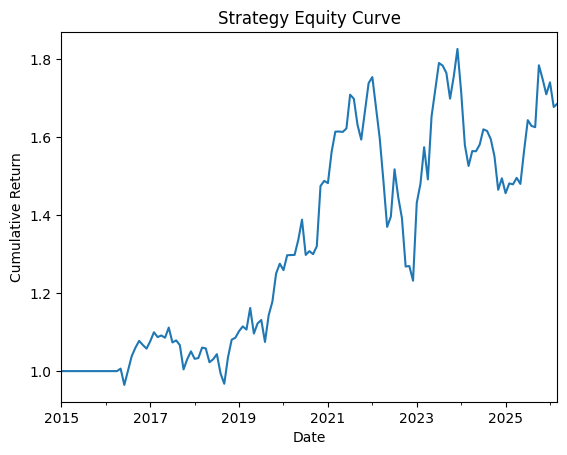

In [28]:
#new_prices = yf.download(univ, start=start_date, end=end_date, auto_adjust=False)['Adj Close']

#monthly_prices = new_prices.resample('ME').last()
#monthly_prices = monthly_prices.iloc[:-1]
#returns = monthly_prices.pct_change()

weight_df.index = weight_df.index.normalize()
#returns.index = returns.index.normalize()
#returns = returns[weight_df.columns]
strat_returns = (weight_df * returns).sum(axis=1)

equity_curve = (1 + strat_returns).cumprod()

equity_curve.plot(title='Strategy Equity Curve')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

In [29]:
sharpe_ratio = strat_returns.mean() / strat_returns.std() * np.sqrt(12)
print(f'Sharpe Ratio: {sharpe_ratio:.2f}')

Sharpe Ratio: 0.41


In [12]:
# get market returns 
market_returns = returns.mean(axis=1)
market_returns

Date
2015-01-31         NaN
2015-02-28    0.058853
2015-03-31   -0.001021
2015-04-30   -0.000386
2015-05-31    0.019554
                ...   
2025-11-30    0.022012
2025-12-31    0.007015
2026-01-31    0.035072
2026-02-28    0.034113
2026-03-31   -0.057459
Freq: ME, Length: 135, dtype: float64

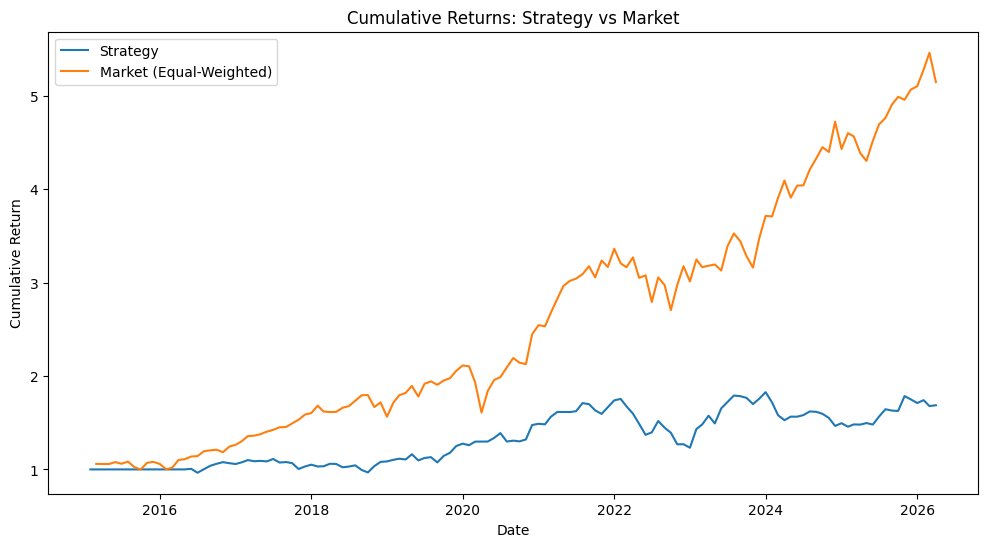

In [30]:
# plot cummulative market returns vs strategy returns as line plot
plt.figure(figsize=(12, 6))
plt.plot((1 + strat_returns).cumprod(), label='Strategy')
plt.plot((1 + market_returns).cumprod(), label='Market (Equal-Weighted)')
plt.title('Cumulative Returns: Strategy vs Market')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()


### Strat and Market Correlation

##### Fairly low, I think its good to assume my strategy mostly consists of pure ALPHA
##### However, we see later that draw downs are destroyers of my strat

In [31]:
(strat_returns.astype(float).corr(market_returns))

np.float64(0.1662990986876082)

### Max Draw down calculations

In [32]:
running_max = equity_curve.cummax()

drawdown = (equity_curve - running_max) / running_max

mdd = drawdown.min()

print("Max Drawdown:", mdd)

Max Drawdown: -0.29779379297798014


<Axes: title={'center': 'Drawdown'}>

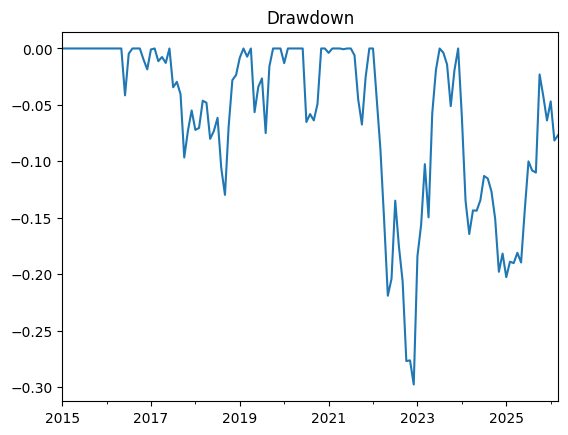

In [33]:
drawdown.plot(title="Drawdown")

##### Time in Drawdown

* Its pretty bad I know but this is exactly the area where risk control comes into play.
* We can say if the draw down passes a certain threshold, we should no longer trade with our current strat and maybe increase the short amount(short bottom 30%) and reduce long (long the top 5%).
* Or we can combined period of max drawdowns with other orthogonal strategy like reversal --> regime switching.

In [34]:
# Boolean: are we in drawdown?
underwater = drawdown < 0

# Count consecutive periods underwater
drawdown_duration = underwater.groupby((underwater != underwater.shift()).cumsum()).cumcount()

max_duration = drawdown_duration.max()

print("Max Drawdown Duration:", max_duration)

Max Drawdown Duration: 26


##### Peak to recovery duration

In [35]:
# Find peaks (where equity == running max)
peaks = equity_curve == running_max

# Track duration since last peak
duration = (~peaks).astype(int)

duration = duration.groupby(peaks.cumsum()).cumsum()

max_duration = duration.max()

print("Max Peak-to-Recovery Duration:", max_duration)

Max Peak-to-Recovery Duration: 27
